<div style="background-color: steelblue; padding: 10px; border-radius: 5px;">
    <p style="margin: 10;"></p>
    <h1 style="text-align: center; margin: 0; font-weight: bold; color: white;">SWOT OMIP : Scatterplot </h1>
    <p style="margin: 10;"></p>
</div>


## 📦**Imports** 

In [59]:
%%time

##################################
#Imports

from datetime import datetime
import s3fs
import xarray as xr
import pyinterp
from widetrax import DataPreprocessing as dp
from widetrax import Spectra as sp
import numpy as np
import json
from watermark import watermark
import time
import platform
from shapely.geometry import shape, box

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
#from widetrax import Spectra as sp
import plot_psd1Xglobal1 as pp2X

CPU times: user 87 μs, sys: 1 μs, total: 88 μs
Wall time: 91.8 μs


## **Load boxes position**

In [60]:
# CONFIG

# NOT MODIFY

roi = {
        "lon_min": -180,
        "lon_max": 180,
        "lat_min": -90,
        "lat_max": 90
}
pos_reg=[-180, -90, 180, 90]

with open("mostly_ocean_boxes_filtered.geojson") as f:
    data = json.load(f)

roi_poly = box(roi["lon_min"], roi["lat_min"],
               roi["lon_max"], roi["lat_max"])

selected = []

for feature in data["features"]:
    poly = shape(feature["geometry"])
    if poly.intersects(roi_poly):
        selected.append(poly)



north_boxes = []
south_boxes = []

for i, feature in enumerate(data["features"]):

    coords = feature["geometry"]["coordinates"][0]

    lats = [c[1] for c in coords]

    lat_center = sum(lats) / len(lats)

    if lat_center >= 0:
        north_boxes.append(i)
    else:
        south_boxes.append(i)

print("North boxes:", len(north_boxes))
print("South boxes:", len(south_boxes))
print(north_boxes)

North boxes: 93
South boxes: 189
[189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275, 276, 277, 278, 279, 280, 281]


## **Plotting boxes**

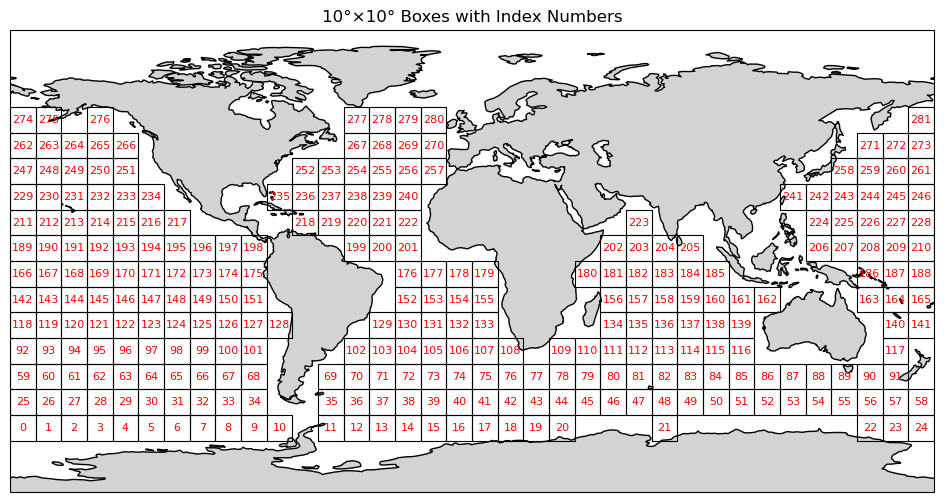

In [61]:

# Load geojson
with open("mostly_ocean_boxes_filtered.geojson") as f:
    data = json.load(f)

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_global()
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.COASTLINE)

for i, feature in enumerate(data["features"]):

    poly = shape(feature["geometry"])

    # Draw box
    ax.add_geometries(
        [poly],
        ccrs.PlateCarree(),
        edgecolor="black",
        facecolor="none",
        linewidth=0.8
    )

    # Get box center
    lon_min, lat_min, lon_max, lat_max = poly.bounds
    lon_c = 0.5 * (lon_min + lon_max)
    lat_c = 0.5 * (lat_min + lat_max)

    # Add number
    ax.text(
        lon_c, lat_c,
        str(i),  # numbering from 1
        transform=ccrs.PlateCarree(),
        ha="center",
        va="center",
        fontsize=8,
        color="red"
    )

ax.set_title("10°×10° Boxes with Index Numbers")
plt.savefig("Fig/boxes.png",dpi=300,transparent=False)
plt.show()

## **Functions**

In [82]:

import numpy as np
import matplotlib.pyplot as plt

def plot_spectral_scatter(ax, k_list, specA_list, specB_list, labelA, labelB):
    vmin = 50    # minimum color value
    vmax = 400   # maximum color value

    x_all = []
    y_all = []
    k_all = []

    for i in range(len(specA_list)):

        k = np.array(k_list[i])
        sA = np.array(specA_list[i])
        sB = np.array(specB_list[i])

        n = min(len(k), len(sA), len(sB))

        x_all.extend(sA[:n])
        y_all.extend(sB[:n])
        k_all.extend(1/k[:n])

    x_all = np.array(x_all)
    y_all = np.array(y_all)
    k_all = np.array(k_all)

    # remove invalid values (needed for log scale)
    mask_valid = (x_all > 0) & (y_all > 0)

    # remove invalid values (needed for log scale)
    #mask_scale = (k_all >= 50) & (k_all <= 500)

    mask = mask_valid# & mask_scale
    x_all=x_all[mask]
    Y_all=y_all[mask]
    k_all=k_all[mask]

    sc = ax.scatter(
        x_all,
        y_all,
        c=k_all,
        vmin=vmin,
        vmax=vmax,
        cmap="nipy_spectral",
        s=10,
        alpha=0.7
    )

    # axis scaling
    ax.set_xscale("log")
    ax.set_yscale("log")

    vmin = min(x_all.min(), y_all.min())
    vmax = max(x_all.max(), y_all.max())

    ax.plot([vmin, vmax], [vmin, vmax], "k--")

    ax.set_xlim(vmin, vmax)
    ax.set_ylim(vmin, vmax)

    ax.set_xlabel(labelA)
    ax.set_ylabel(labelB)

    return sc

In [71]:
def load_spectr(season,imod):
    spectrum=[]
    freq=[]

    box=0
    for i, poly in enumerate(selected):
        # Plot spectrum JFM
        filename = "GLOBALv2/" + imod +  "/Global_box_" + str(box) + "_" + season + "_" + imod + ".json"
        with open(filename, "r") as f:
            data = json.load(f)
        spectrum.append(data["Spectra"])
        freq.append(data["Frequency"])
        box=box+1

    sselected = []
    fselected = []
    for ibox in range(282):
        scale = 1/np.array(freq[ibox])
        spec = np.array(spectrum[ibox])
        freq2=np.array(freq[ibox])
        # Create mask for the frequency range
        mask = (scale <= 500) & (scale >= 50)
    
        # Apply mask
        sselected.append(spec[mask])
        fselected.append(freq2[mask])
    
    return sselected, fselected

In [86]:
def load_spectr_region(season,imod,posbox):
    spectrum=[]
    freq=[]

    box=0
    for i, poly in enumerate(selected):
        # Plot spectrum JFM
        filename = "GLOBALv2/" + imod +  "/Global_box_" + str(box) + "_" + season + "_" + imod + ".json"
        with open(filename, "r") as f:
            data = json.load(f)
        spectrum.append(data["Spectra"])
        freq.append(data["Frequency"])
        box=box+1

    sselected = []
    fselected = []
    
    for ibox in posbox:
        scale = 1/np.array(freq[ibox])
        spec = np.array(spectrum[ibox])
        freq2=np.array(freq[ibox])
        # Create mask for the frequency range
        mask = (scale <= 500) & (scale >= 50)
    
        # Apply mask
        sselected.append(spec[mask])
        fselected.append(freq2[mask])
    
    return sselected, fselected

In [85]:
def find_posbox_lat(latmin,latmax):

    with open("mostly_ocean_boxes_filtered.geojson") as f:
        data = json.load(f)

    pos_boxes = []

    for i, feature in enumerate(data["features"]):

        coords = feature["geometry"]["coordinates"][0]

        lats = [c[1] for c in coords]

        lat_center = sum(lats) / len(lats)

        if (lat_center >= latmin) & (lat_center <= latmax):
            pos_boxes.append(i)

    return pos_boxes



## **Plotting**

In [64]:
s0, freq=load_spectr(season,model[0])



/var/folders/c9/n_765b212hs2ss0sxlp635dr0000gp/T/ipykernel_5949/172896480.py:5: RuntimeWarning: divide by zero encountered in divide
  scale = 1/np.array(freq[ibox])


In [66]:
fselected

[array([0.00255102, 0.00340136, 0.0042517 , 0.00510204, 0.00595238,
        0.00680272, 0.00765306, 0.0085034 , 0.00935374, 0.01020408,
        0.01105442, 0.01190476, 0.0127551 , 0.01360544, 0.01445578,
        0.01530612, 0.01615646, 0.0170068 , 0.01785714, 0.01870748,
        0.01955782]),
 array([0.00253378, 0.00337838, 0.00422297, 0.00506757, 0.00591216,
        0.00675676, 0.00760135, 0.00844595, 0.00929054, 0.01013514,
        0.01097973, 0.01182432, 0.01266892, 0.01351351, 0.01435811,
        0.0152027 , 0.0160473 , 0.01689189, 0.01773649, 0.01858108,
        0.01942568]),
 array([0.00254237, 0.00338983, 0.00423729, 0.00508475, 0.0059322 ,
        0.00677966, 0.00762712, 0.00847458, 0.00932203, 0.01016949,
        0.01101695, 0.01186441, 0.01271186, 0.01355932, 0.01440678,
        0.01525424, 0.01610169, 0.01694915, 0.01779661, 0.01864407,
        0.01949153]),
 array([0.0025641 , 0.0034188 , 0.0042735 , 0.00512821, 0.00598291,
        0.00683761, 0.00769231, 0.00854701, 0.0094

/var/folders/c9/n_765b212hs2ss0sxlp635dr0000gp/T/ipykernel_5949/2650824655.py:18: RuntimeWarning: divide by zero encountered in divide
  scale = 1/np.array(freq[ibox])
/var/folders/c9/n_765b212hs2ss0sxlp635dr0000gp/T/ipykernel_5949/308464482.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


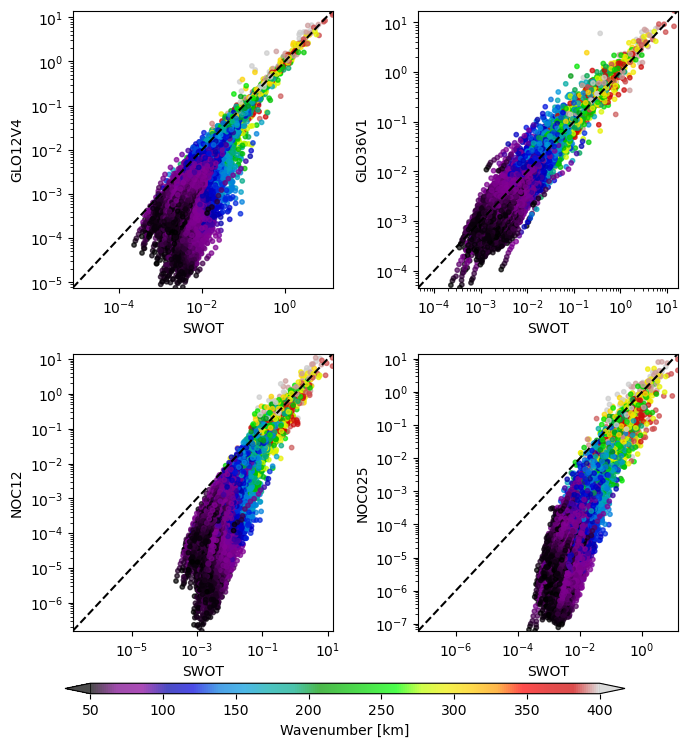

In [104]:


season="JFM"


#MODEL LOAD
models=["GLO12","GLO36","NOC12","NOC025","SWOT"]

model= ["GLO12V4","GLO36V1","NOC12","NOC025","SWOT"]
import matplotlib.pyplot as plt



s0, freq=load_spectr(season,model[0])
s1, freq=load_spectr(season,model[1])
s2, freq=load_spectr(season,model[2])
s3, freq=load_spectr(season,model[3])
s4, freq=load_spectr(season,model[4])

fig, ax = plt.subplots(2,2,figsize=(7,7))

sc0 = plot_spectral_scatter(ax[0,0],freq,s4,s0,"SWOT", model[0])
sc1 = plot_spectral_scatter(ax[0,1],freq,s4,s1,"SWOT", model[1])
sc2 = plot_spectral_scatter(ax[1,0],freq,s4,s2,"SWOT", model[2])
sc3 = plot_spectral_scatter(ax[1,1],freq,s4,s3,"SWOT", model[3])

cbar_ax = fig.add_axes([0.1, 0.0, .8, 0.015])
cbar = fig.colorbar(sc3,cax=cbar_ax, orientation='horizontal', fraction=0.02,  extend='both')
cbar.set_label("Wavenumber [km]")
plt.tight_layout()
plt.savefig("Fig/scatter_global_"+season+".png",dpi=300,transparent=False, bbox_inches="tight")


plt.show()


## **Defining latitude**

/var/folders/c9/n_765b212hs2ss0sxlp635dr0000gp/T/ipykernel_5949/4770879.py:19: RuntimeWarning: divide by zero encountered in divide
  scale = 1/np.array(freq[ibox])
/var/folders/c9/n_765b212hs2ss0sxlp635dr0000gp/T/ipykernel_5949/4283539124.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


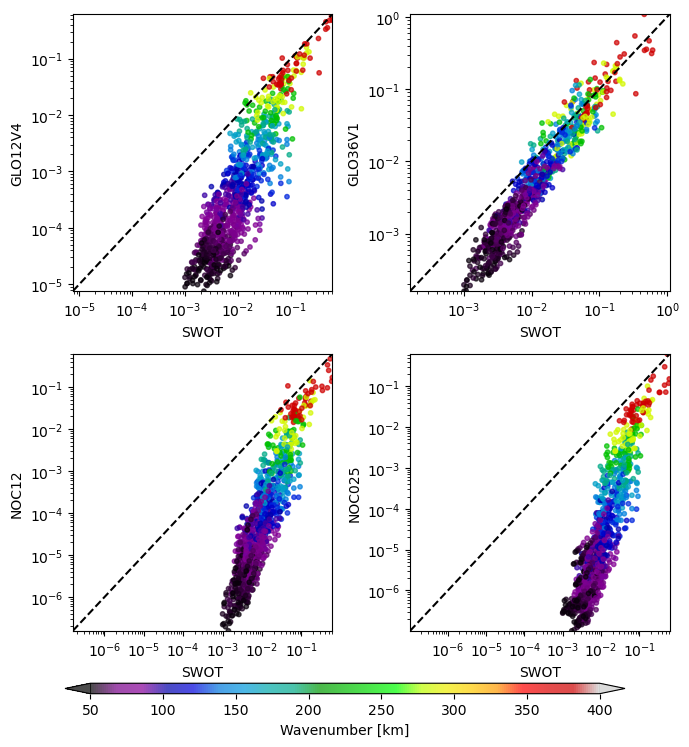

In [118]:
season="JFM"

latmin=-25
latmax=0
poslat=find_posbox_lat(latmin,latmax)
#MODEL LOAD
models=["GLO12","GLO36","NOC12","NOC025","SWOT"]

model= ["GLO12V4","GLO36V1","NOC12","NOC025","SWOT"]
import matplotlib.pyplot as plt



s0, freq=load_spectr_region(season,model[0],poslat)
s1, freq=load_spectr_region(season,model[1],poslat)
s2, freq=load_spectr_region(season,model[2],poslat)
s3, freq=load_spectr_region(season,model[3],poslat)
s4, freq=load_spectr_region(season,model[4],poslat)

fig, ax = plt.subplots(2,2,figsize=(7,7))

sc0 = plot_spectral_scatter(ax[0,0],freq,s4,s0,"SWOT", model[0])
sc1 = plot_spectral_scatter(ax[0,1],freq,s4,s1,"SWOT", model[1])
sc2 = plot_spectral_scatter(ax[1,0],freq,s4,s2,"SWOT", model[2])
sc3 = plot_spectral_scatter(ax[1,1],freq,s4,s3,"SWOT", model[3])

cbar_ax = fig.add_axes([0.1, 0.0, .8, 0.015])
cbar = fig.colorbar(sc3,cax=cbar_ax, orientation='horizontal', fraction=0.02,  extend='both')
cbar.set_label("Wavenumber [km]")
plt.tight_layout()

plt.savefig("Fig/scatter_"+str(latmin)+"-"+str(latmax)+"_"+season+".png",
            dpi=300, transparent=False, bbox_inches="tight")
plt.show()
